# Exercise 2

In [1]:
# Versions used incase of any issues 
import sys 
import pkg_resources as pkg
print("Python:", sys.version)
print("numpy:", pkg.get_distribution("numpy").version)
print("pandas:", pkg.get_distribution("pandas").version)
print("scikit-learn:", pkg.get_distribution("scikit-learn").version)
print("matplotlib:", pkg.get_distribution("matplotlib").version)
print("seaborn", pkg.get_distribution("seaborn").version)
print("tensorflow:", pkg.get_distribution("tensorflow").version)
print("keras:", pkg.get_distribution("keras").version)

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
numpy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn 0.13.2
tensorflow: 2.20.0
keras: 3.11.3


C:\Users\nikolapf\AppData\Local\Temp\ipykernel_17376\3414704316.py:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources as pkg


In [2]:
import pandas as pd
import numpy as np
from seaborn import heatmap, histplot, pairplot, barplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

from keras.models import Sequential 
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping

In [3]:
# a) 
df = pd.read_csv("Electricity_Prices.csv")
df.head()

,datetime,hour,dayofweek,month,demand_mw,temperature,renewable_share,fuel_price_index,price_eur_mwh
0,2024-01-01 00:00:00,0,0,1,4062.837404,1.203237,0.253898,41.620932,98.878838
1,2024-01-01 01:00:00,1,0,1,3982.503576,-5.596776,0.265987,41.170110,102.251139
2,2024-01-01 02:00:00,2,0,1,4128.368713,-5.273660,0.234672,40.661759,94.940081
3,2024-01-01 03:00:00,3,0,1,4305.605699,0.025729,0.286478,40.962829,97.109801
4,2024-01-01 04:00:00,4,0,1,4107.514446,-1.904013,0.213370,40.278259,99.969860


In [24]:
df.describe()

,hour,dayofweek,month,demand_mw,temperature,renewable_share,fuel_price_index,price_eur_mwh
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,11.500000,2.991781,6.498630,3554.575691,8.027218,0.221276,48.739040,99.151532
std,6.922582,2.003519,3.444171,615.129221,7.703307,0.063906,5.274667,10.237607
min,0.000000,0.000000,1.000000,2024.506315,-12.627907,0.060642,36.283218,67.645406
25%,5.750000,1.000000,4.000000,3027.965262,1.370635,0.170269,44.306584,91.803064
50%,11.500000,3.000000,7.000000,3551.306039,8.009345,0.222763,48.741773,98.313114
75%,17.250000,5.000000,9.000000,4093.276535,14.677916,0.265247,53.112079,105.702145
max,23.000000,6.000000,12.000000,5159.629919,28.123824,0.426548,61.634671,136.785794


In [4]:
# b)
df = df.set_index("datetime")

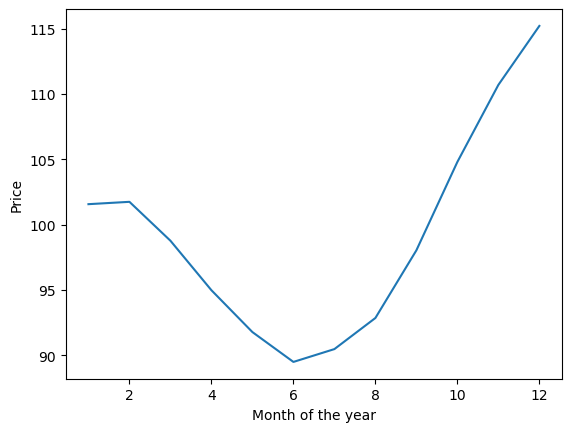

In [5]:
# c) 
df.groupby("month")["price_eur_mwh"].mean().plot()
plt.xlabel("Month of the year")
plt.ylabel("Price")
plt.show()

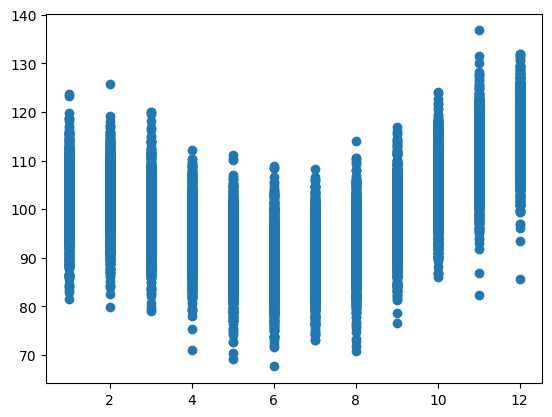

In [6]:
plt.scatter(df["month"], df["price_eur_mwh"])
plt.show()

Both plot show that the price is higher in the winter months, this makes sense based on logical thinking. Howver there is a large spread in spot price in all months, this is likley because of other factors

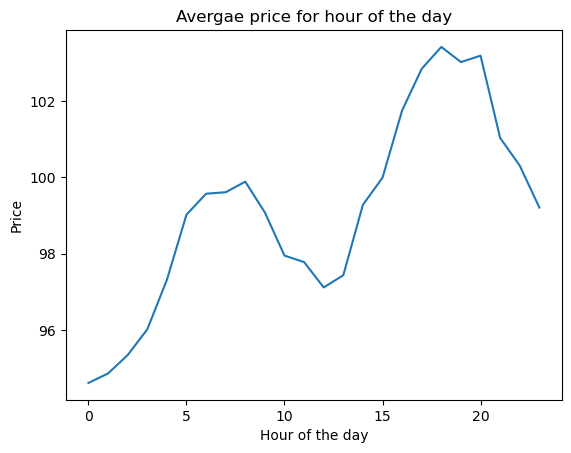

In [7]:
# d)
df.groupby("hour")["price_eur_mwh"].mean().plot()
plt.xlabel("Hour of the day")
plt.ylabel("Price")
plt.title("Avergae price for hour of the day")
plt.show()

This shows that the price is higher in the morning before people go to work, then dip in the typical working hours before they go back up to an all day high around dinner time for most households. This makes sense because the spot price is driven by demand in most markets

In [8]:
# e)
list(df.columns)

['hour',
 'dayofweek',
 'month',
 'demand_mw',
 'temperature',
 'renewable_share',
 'fuel_price_index',
 'price_eur_mwh']

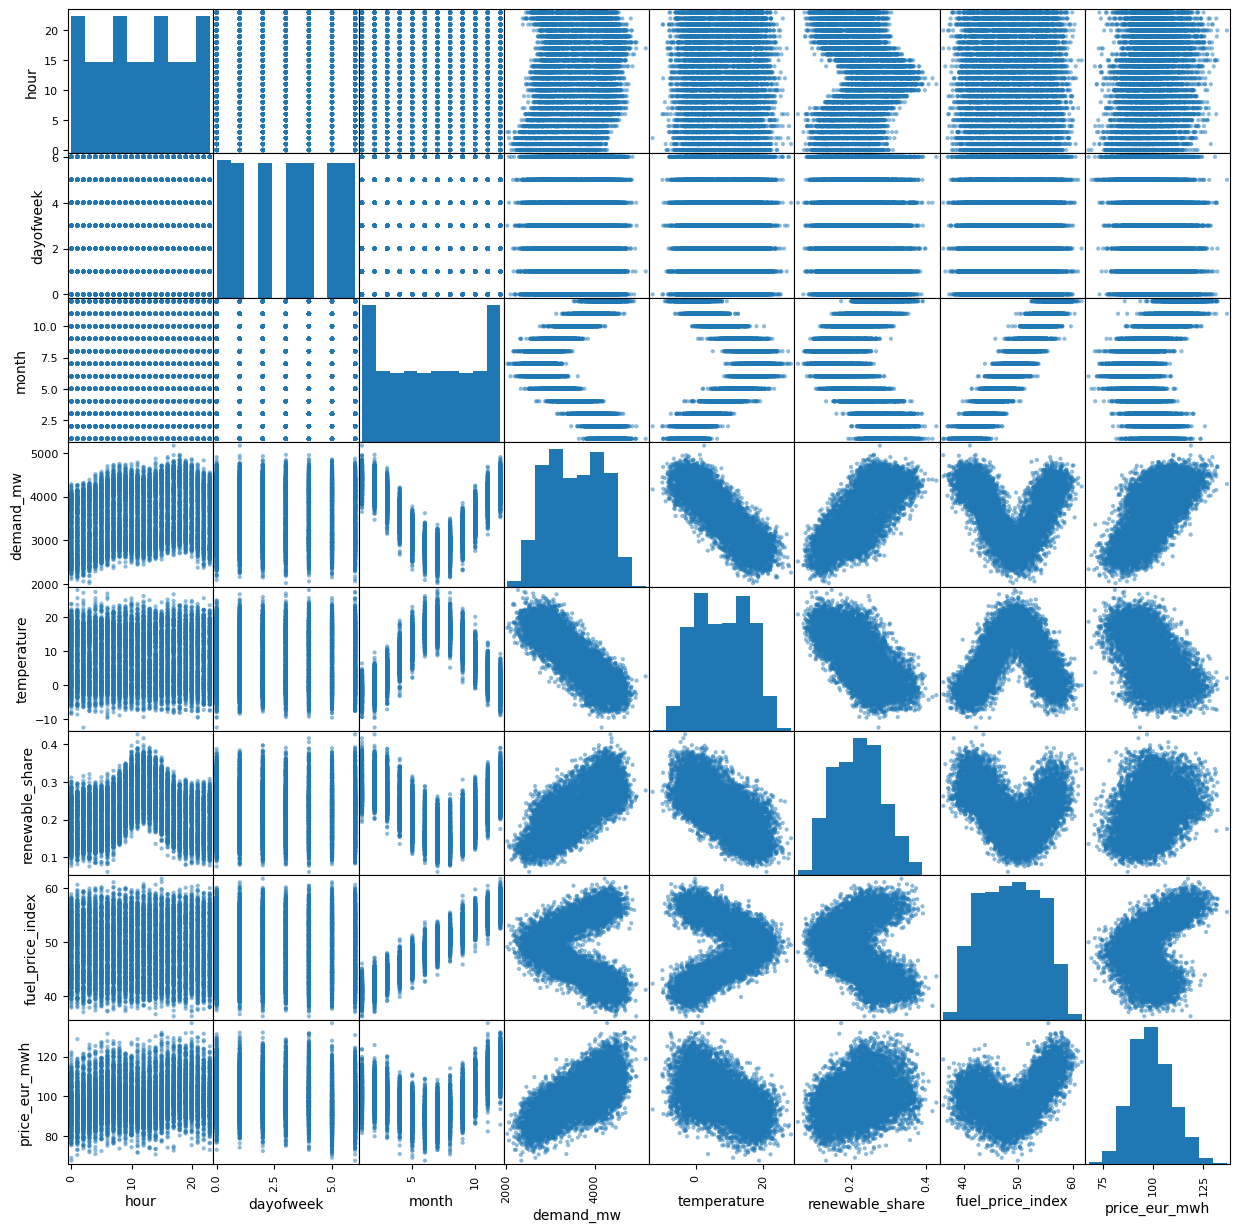

In [9]:
pd.plotting.scatter_matrix(df[["hour", "dayofweek", "month", "demand_mw", "temperature", "renewable_share", "fuel_price_index", "price_eur_mwh"]], figsize = (15, 15))
plt.show()

We see alot of V shapes like the one we have observed between month and price, this seems to indicate that the price is likley highly decided by the time of year. We also so a linear relationship between price and demand

### Preparing the data

In [10]:
# f)
y = df["price_eur_mwh"]
X = df.drop(["price_eur_mwh"], axis = 1)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = .8, random_state = 42)

#### g)

### Linear Refression Model

In [12]:
model = LinearRegression()

In [13]:
model = model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_score_train = r2_score(y_train, y_train_pred)
r2_score_test = r2_score(y_test, y_test_pred)

MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_test = mean_absolute_error(y_test, y_test_pred)

MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_test = mean_squared_error(y_test, y_test_pred)

print("The r2 score on the train set:", r2_score_train)
print("The MAE on the train set:", MAE_train)
print("The MSE on the train set:", MSE_train)
print("")
print("The r2 score on the test set:", r2_score_test)
print("The MAE on the test set:", MAE_test)
print("The MSE on the test set:", MSE_test)

The r2 score on the train set: 0.7427240534286419
The MAE on the train set: 4.151027370829081
The MSE on the train set: 26.95543177540465

The r2 score on the test set: 0.7382520754043465
The MAE on the test set: 4.1705907951733305
The MSE on the test set: 27.452489112537474


We see that the model performs equall on the train and test set so we assume that it is not overfitting, 0,74 shows that our model is performing at a good level. The mean absolute error is also accepteple at 4 meaning in general we predict 4 euros off, however the mean sqaured error seems to be a little high based on the fact that the average price is around 100

### Decision Tree

In [14]:
model = DecisionTreeRegressor(random_state = 42)

In [15]:
model = model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_score_train = r2_score(y_train, y_train_pred)
r2_score_test = r2_score(y_test, y_test_pred)

MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_test = mean_absolute_error(y_test, y_test_pred)

MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_test = mean_squared_error(y_test, y_test_pred)

print("The r2 score on the train set:", r2_score_train)
print("The MAE on the train set:", MAE_train)
print("The MSE on the train set:", MSE_train)
print("")
print("The r2 score on the test set:", r2_score_test)
print("The MAE on the test set:", MAE_test)
print("The MSE on the test set:", MSE_test)

The r2 score on the train set: 1.0
The MAE on the train set: 0.0
The MSE on the train set: 0.0

The r2 score on the test set: 0.5075914525614601
The MAE on the test set: 5.673896069319541
The MSE on the test set: 51.64449845537143


Based on all the train set scores we see our model is clearly overfitting, this is a usual problem with decision tree models with no restrictions. We will need some retrictions to get a meaningfull model

In [16]:
model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state = 42)

In [17]:
model = model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_score_train = r2_score(y_train, y_train_pred)
r2_score_test = r2_score(y_test, y_test_pred)

MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_test = mean_absolute_error(y_test, y_test_pred)

MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_test = mean_squared_error(y_test, y_test_pred)

print("The r2 score on the train set:", r2_score_train)
print("The MAE on the train set:", MAE_train)
print("The MSE on the train set:", MSE_train)
print("")
print("The r2 score on the test set:", r2_score_test)
print("The MAE on the test set:", MAE_test)
print("The MSE on the test set:", MSE_test)

The r2 score on the train set: 0.7344598487359087
The MAE on the train set: 4.226748881232948
The MSE on the train set: 27.82129276529382

The r2 score on the test set: 0.7054531653783285
The MAE on the test set: 4.37933428201769
The MSE on the test set: 30.89248475637421


We see that the model performs pretty equal to the linear regression model, however it seems to perform a little worse on the test set on all parameters, but not enough to say it is overfitting in my opinion.

### ANN

In [18]:
# To help train the ANN I will scale the data 
X_scaler = MinMaxScaler(feature_range = (0, 1))

X_sc = X_scaler.fit_transform(X)

# Put the X back into a dataframe
X_sc = pd.DataFrame(X_sc, columns = X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_sc, y, train_size = .8, random_state = 42)

In [19]:
n_features = X_train.shape[1]
n_classes = len(y_train.unique())

model = Sequential()
model.add(Dense(16, input_dim = n_features, activation = "relu"))
model.add(Dense(16, activation = "relu"))
model.add(Dense(1, activation = "linear"))

# Tells the model what to minimize
model.compile(loss = "mean_squared_error", optimizer = "adam")

early_stop = EarlyStopping(monitor = "loss", patience = 2, verbose = 1)

C:\Programs\Anaconda3\2025.06\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Because this is time series data I choose to not shuffle
history = model.fit(X_train, y_train, epochs = 100, batch_size = 1, verbose = 0, callbacks = [early_stop], shuffle = False)

In [22]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

r2_score_train = r2_score(y_train, y_train_pred)
r2_score_test = r2_score(y_test, y_test_pred)

MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_test = mean_absolute_error(y_test, y_test_pred)

MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_test = mean_squared_error(y_test, y_test_pred)

print("The r2 score on the train set:", r2_score_train)
print("The MAE on the train set:", MAE_train)
print("The MSE on the train set:", MSE_train)
print("")
print("The r2 score on the test set:", r2_score_test)
print("The MAE on the test set:", MAE_test)
print("The MSE on the test set:", MSE_test)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step
The r2 score on the train set: 0.7378660209290206
The MAE on the train set: 4.184148759468007
The MSE on the train set: 27.46441975252174

The r2 score on the test set: 0.7339329143971619
The MAE on the test set: 4.222833472697949
The MSE on the test set: 27.905488771305347


From the Artificial Neural Network we also get similar results to the other models, we see that it performs equall on both sets aswell meaning it does not overfit

### h)

## Conclusion

#### Scores  
All models performed well on both sets explaining  about 70-75% of the data. In general the MAE was around 4 - 4,5 meaning on average the predicted and observed price had a 4 euro diffrence, based on the mean on 100 on the target variable this is good. MSE or the means of all the residuals sqaured was around 27-28, this is fine however it would be best if this was abit lower considering the dataset.

#### Ways to improve performance

**Linear Regression model:** I think the best way to improve this model is by removing some variables. Based on the scatter plots alot of the varables are not independent, this makes our linear model perform worse because we get a bias. We see demand has a linear relationship with alot of the other variables, this means the effect demand has on price could be overexplaning in our model. We could start by removing for example day of the week because the diffrence in demand on weekends will be picked up by the demand variable anyway. 

**Decision Tree:** The best way to improve this model is to prune it by finding the ideal alpha. The alpha decides how many branches our tree has and in this case we would assume a simples model would perform better because it seems like time of day and time of year are the driving factors. Therefore I would expect the ideal alpha to be high, meaning more branches are removed and we get a simpler model.

**Artificial Neural Network:** To improve the performance of the ANN we could add more layers or nodes, we could also train it on an higher epochs meaning it would go through the dataset more times. All this would improve the performance, however it would also increse the computing power and time it would take to train the model. On larger datesets this is a crucial decision because some neural networks could take days to train.